In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import glob, os
import numpy as np
import matplotlib.colors as mcolors

In [2]:
# Load csv file stored into:     output_path = Path("/home/clevyfidel/Documents/Workspace/RNN_paradigm/RNN/exp_seq_act_output") / model_name
# out_file = output_path / (trial_file.stem + '_activations.csv'
# out_df.to_csv(out_file, index=False)
act_df = pd.read_csv("/home/clevyfidel/Documents/Workspace/RNN_paradigm/RNN/exp_seq_act_output/population_network_all_bn8_lr0/correlation_scores/exp_trials_correlations.csv", index_col=0)
act_df.sort_values(by=['lim_std', 'd', 'tau_std'], inplace=True)

## Pairs of modules - correlations between modules

### OBS-CTX

Effect of lim_std (no effect of tau_std, d taken individually, not shown; nor combined, shown in second plot)

<Axes: xlabel='activity_obs_ctx', ylabel='Count'>

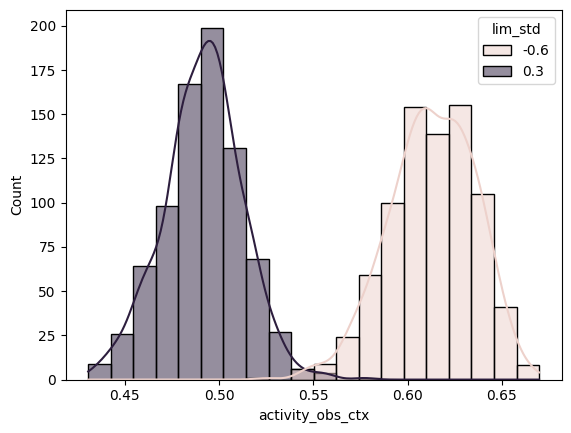

In [3]:
sns.histplot(data=act_df, x='activity_obs_ctx', bins=20, kde=True, hue='lim_std')

<Axes: xlabel='activity_obs_ctx', ylabel='Count'>

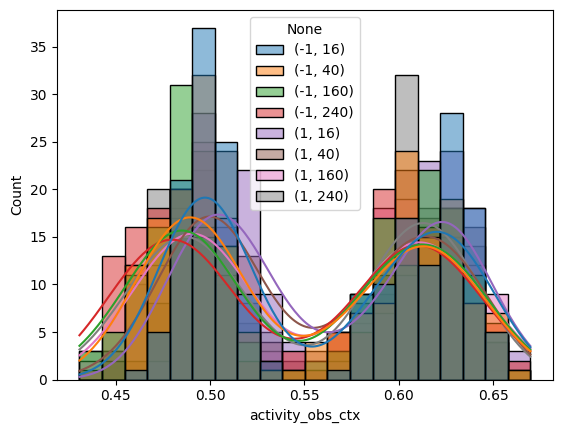

In [4]:
sns.histplot(data=act_df, x='activity_obs_ctx', bins=20, kde=True, hue=act_df[['d', 'tau_std']].apply(tuple, axis=1))
## --> no effect of d and tau_std combined

### OBS-DPOS

Effect of lim_std

<Axes: xlabel='activity_obs_dpos', ylabel='Count'>

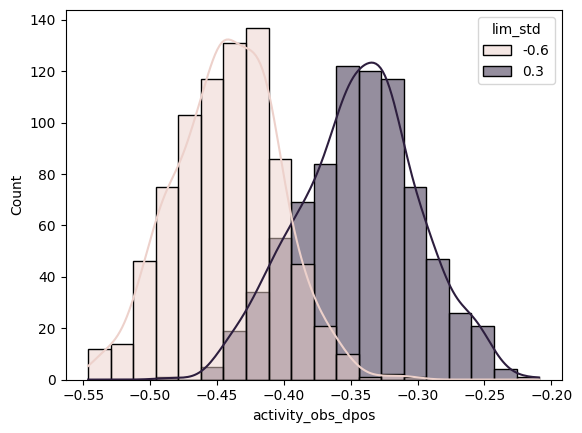

In [6]:
sns.histplot(data=act_df, x='activity_obs_dpos', bins=20, kde=True, hue='lim_std')

### CTX-DPOS

Different distributions profiles emerge when showing all 3-level combinations  individually

2 distinct profiles emerge when showing lim_std and d combined:
- group 1: (lim_std = -0.6, d = -1) & (lim_std = 0.3, d = 1)
- group 2: (lim_std = -0.6, d = 1) & (lim_std = 0.3, d = -1)

<Axes: xlabel='activity_ctx_dpos', ylabel='Count'>

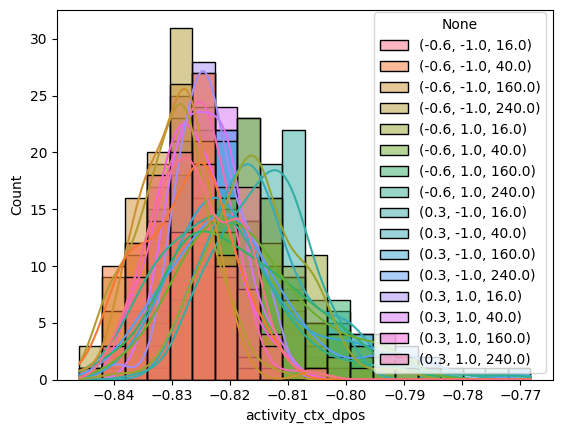

In [7]:
sns.histplot(data=act_df, x='activity_ctx_dpos', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1))

<Axes: xlabel='activity_ctx_dpos', ylabel='Count'>

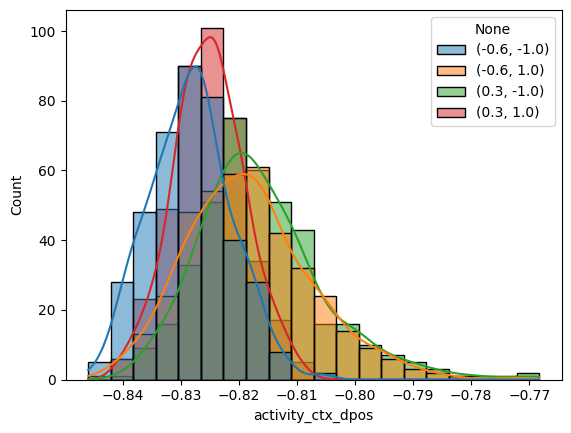

In [8]:
sns.histplot(data=act_df, x='activity_ctx_dpos', bins=20, kde=True, hue=act_df[['lim_std', 'd']].apply(tuple, axis=1))

### CTX-RULE

Different distributions profiles emerge when showing all 3-level combinations  individually

2 distinct profiles emerge when showing lim_std and d combined:
- group 1: (lim_std = -0.6, d = -1) & (lim_std = 0.3, d = 1)
- group 2: (lim_std = -0.6, d = 1) & (lim_std = 0.3, d = -1)

<Axes: xlabel='activity_ctx_rule', ylabel='Count'>

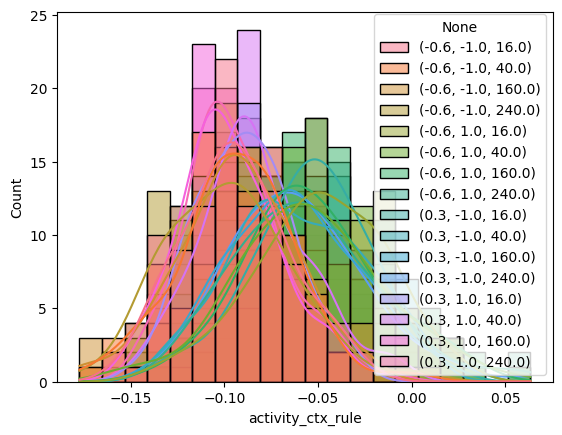

In [33]:
sns.histplot(data=act_df, x='activity_ctx_rule', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1))

<Axes: xlabel='activity_ctx_rule', ylabel='Count'>

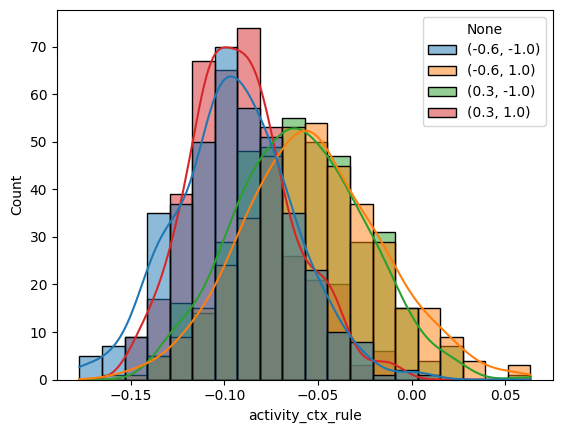

In [9]:
sns.histplot(data=act_df, x='activity_ctx_rule', bins=20, kde=True, hue=act_df[['lim_std', 'd']].apply(tuple, axis=1))

### DPOS-RULE

No clear effect... even some 3-level combinations show bi-modal dists (-0.6, -1, 160; -0.6, 1, 160?)

<Axes: xlabel='activity_dpos_rule', ylabel='Count'>

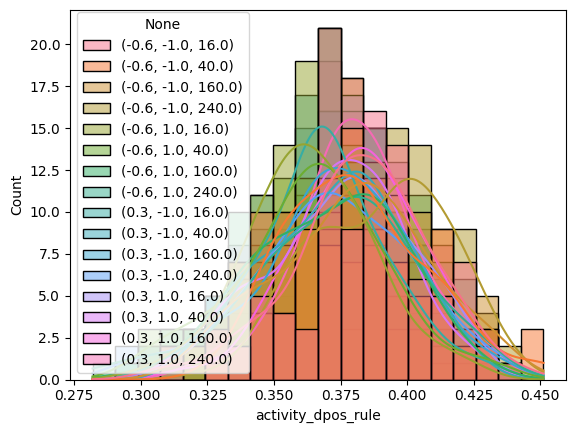

In [10]:
sns.histplot(data=act_df, x='activity_dpos_rule', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1))

### MEAN

- Effect of lim_std + d
- tau_std has different effects in the different combinations of lim_std + d

<Axes: xlabel='activity_mean', ylabel='Count'>

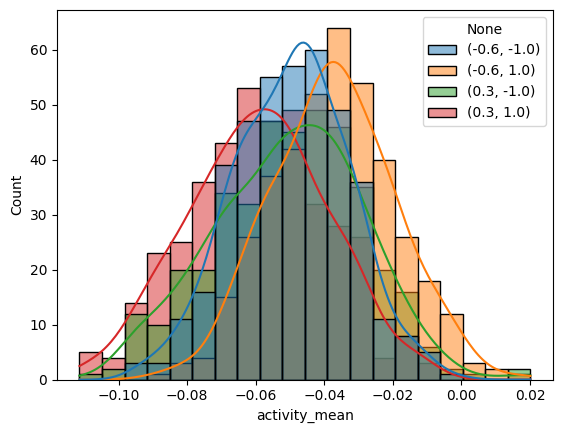

In [11]:
sns.histplot(data=act_df, x='activity_mean', bins=20, kde=True, hue=act_df[['lim_std', 'd']].apply(tuple, axis=1))

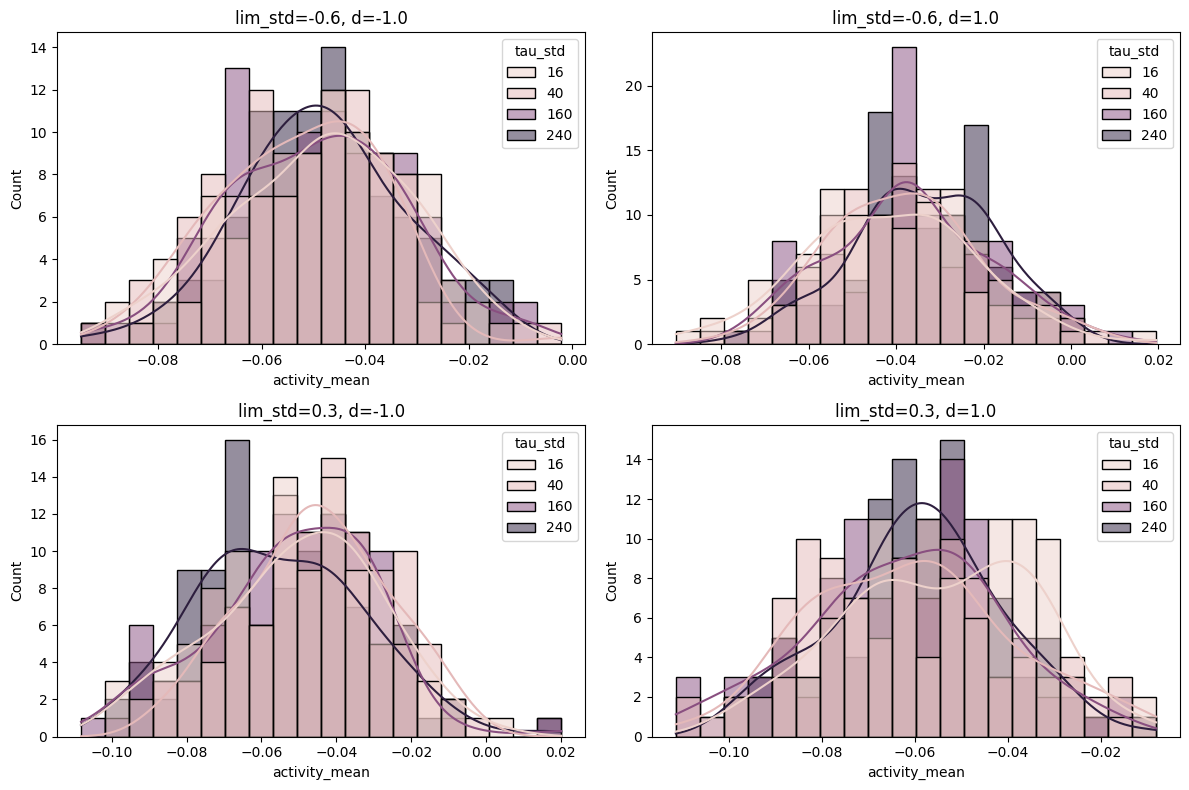

In [12]:
# for each combination of lim_std and d (there are 4 combinations in total), plot a subplot in a figure and put tau_std as a hue in the histogram of activity_mean
fig, axs = plt.subplots(2, 2, figsize=(12, 8))
for i, (lim_std, d) in enumerate(act_df[['lim_std', 'd']].drop_duplicates().values):
    ax = axs[i // 2, i % 2]
    subset = act_df[(act_df['lim_std'] == lim_std) & (act_df['d'] == d)]
    sns.histplot(data=subset, x='activity_mean', bins=20, kde=True, hue='tau_std', ax=ax)
    ax.set_title(f'lim_std={lim_std}, d={d}')
fig.tight_layout()

<Axes: xlabel='activity_mean', ylabel='Count'>

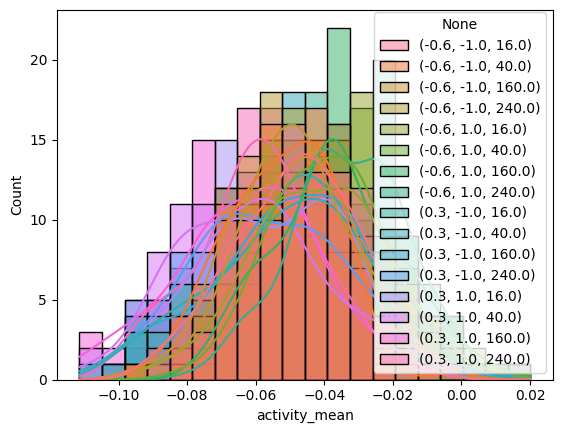

In [13]:
# cmap = sns.color_palette("Purples", 4) + sns.color_palette("YlOrRd", 4) + sns.color_palette("Blues", 4) + sns.color_palette("Greens", 4)
# sns.histplot(data=act_df, x='activity_mean', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1), palette=cmap)

sns.histplot(data=act_df, x='activity_mean', bins=20, kde=True, hue=act_df[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1))

**Check whether average activities that are closest to zero also display activity closest to zero in as many modules pairs as possible**

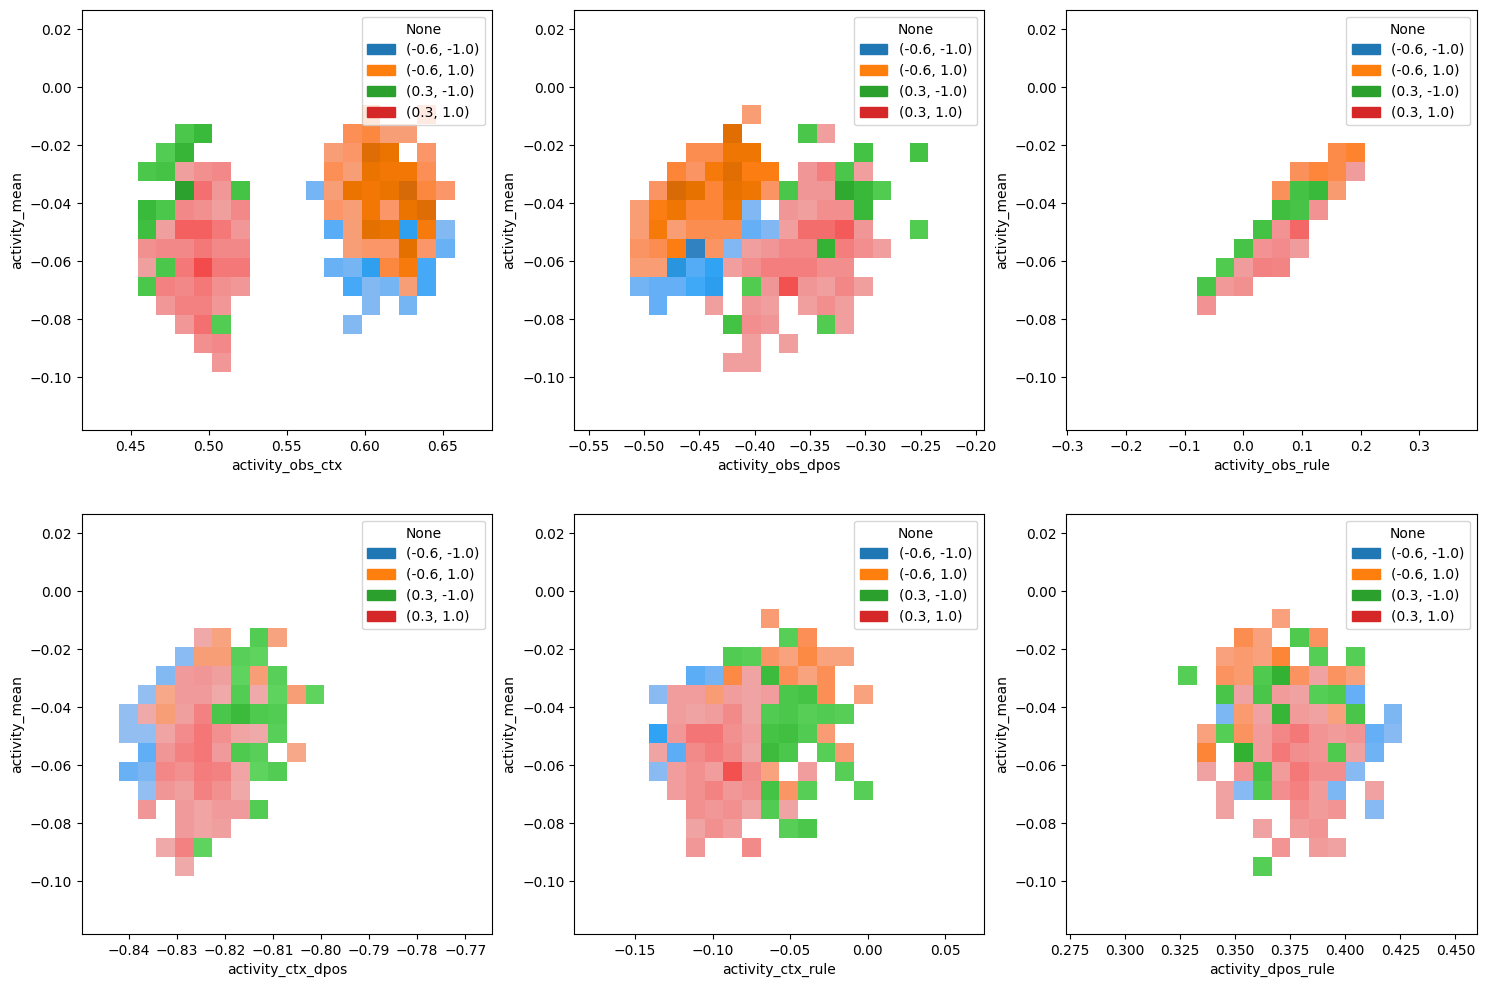

In [14]:
# For each 'activity_obs_ctx', 'activity_obs_dpos', 'activity_obs_rule', 'activity_ctx_dpos', 'activity_ctx_rule', 'activity_dpos_rule', plot a 2D-hist between the selected column and 'activity_mean'
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
activity_columns = ['activity_obs_ctx', 'activity_obs_dpos', 'activity_obs_rule',
                    'activity_ctx_dpos', 'activity_ctx_rule', 'activity_dpos_rule']
for i, col in enumerate(activity_columns):
    ax = axs[i // 3, i % 3]
    sns.histplot(data=act_df, x=col, y='activity_mean', bins=20, pthresh=.1, cmap="mako", ax=ax, hue=act_df[['lim_std', 'd']].apply(tuple, axis=1))


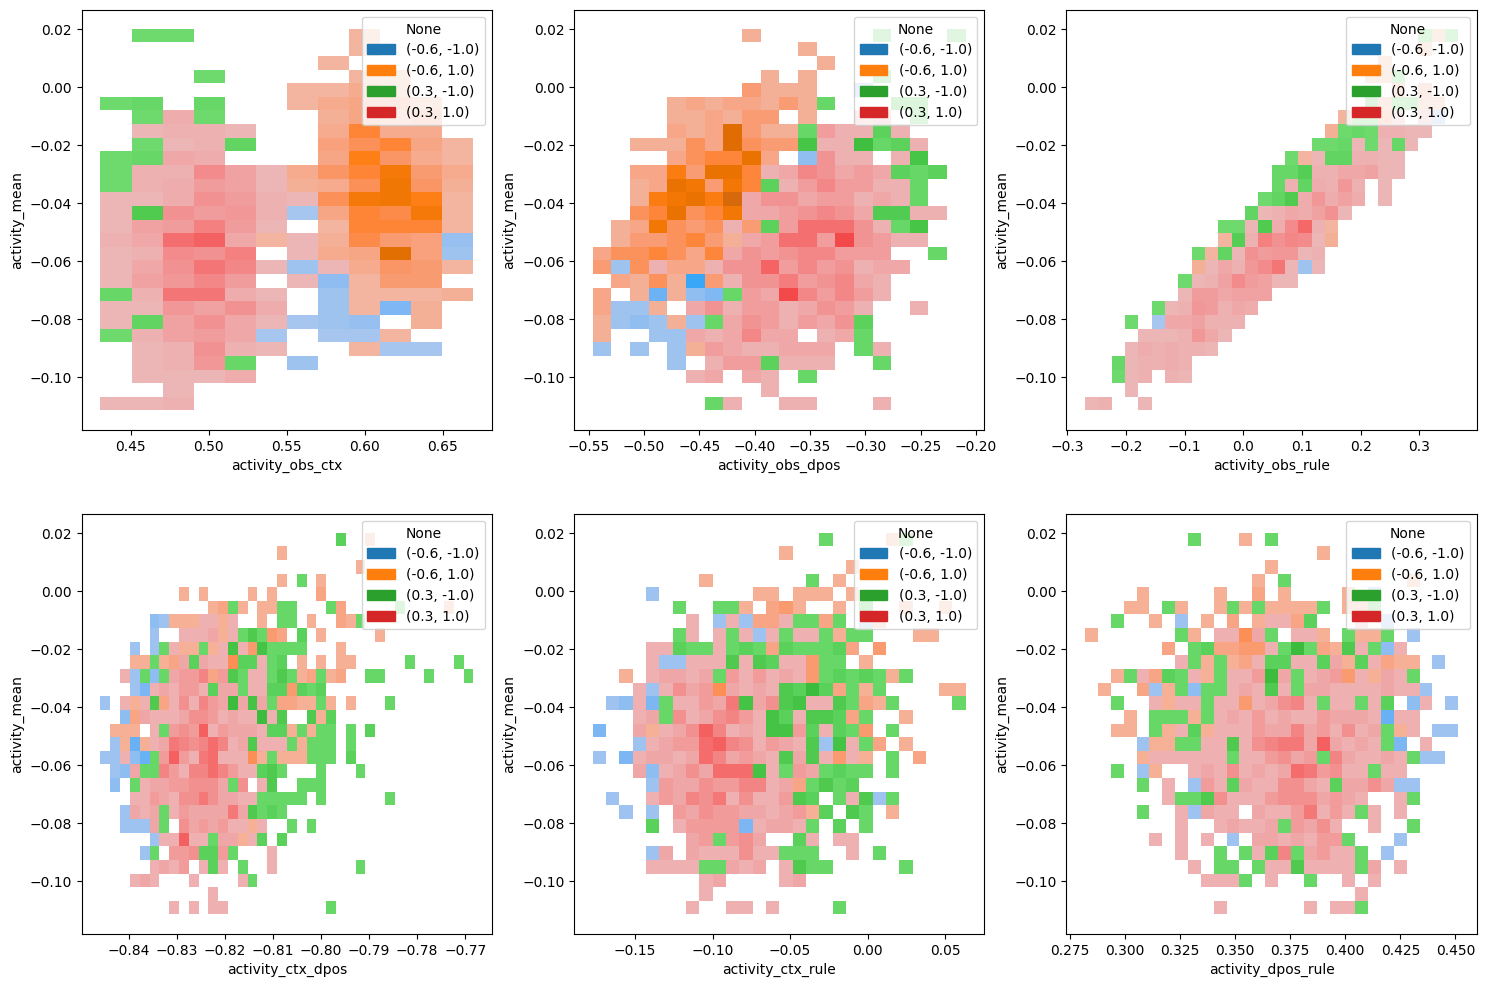

In [15]:
# For each 'activity_obs_ctx', 'activity_obs_dpos', 'activity_obs_rule', 'activity_ctx_dpos', 'activity_ctx_rule', 'activity_dpos_rule', plot a 2D-hist between the selected column and 'activity_mean'
fig, axs = plt.subplots(2, 3, figsize=(18, 12))
activity_columns = ['activity_obs_ctx', 'activity_obs_dpos', 'activity_obs_rule',
                    'activity_ctx_dpos', 'activity_ctx_rule', 'activity_dpos_rule']
for i, col in enumerate(activity_columns):
    ax = axs[i // 3, i % 3]
    sns.histplot(data=act_df, x=col, y='activity_mean', ax=ax, hue=act_df[['lim_std', 'd']].apply(tuple, axis=1))


## Module-to-module associations within and across sequences

### Per combination of (lim_std, d)

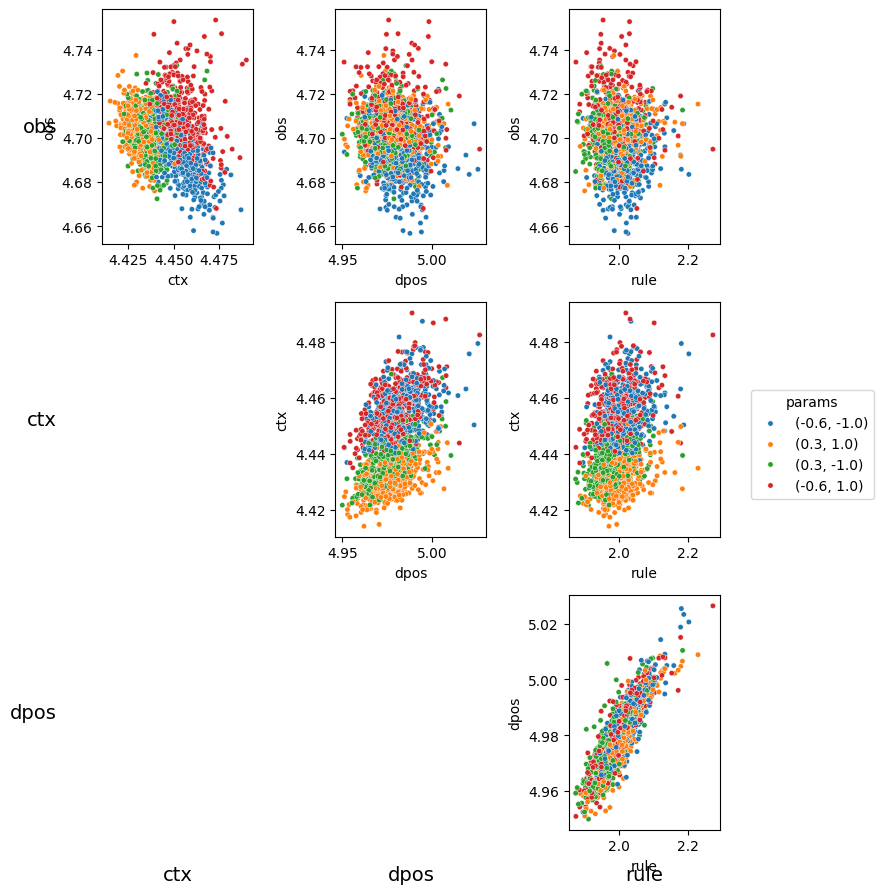

In [17]:
# Plot matrix (we only care about the upper triangle so we can leave the diagonal and lower triangle empty) showing scatterplot association between the activaty of two modules
# For this, we shouldn't use the correlation scores files but the activity files which are stored in /home/clevyfidel/Documents/Workspace/RNN_paradigm/RNN/exp_seq_act_output/population_network_all_bn8_lr0/activations. Each dot should show the association of the mean activity of two modules for one sequence. So there should be as many dots in each plot as sequences.

activations_folder = "/home/clevyfidel/Documents/Workspace/RNN_paradigm/RNN/exp_seq_act_output/population_network_all_bn8_lr0/activations"

modules = ['obs', 'ctx', 'dpos', 'rule']

# One file = one sequence. Compute the mean activity of each module within that sequence.
records = []
for f in sorted(glob.glob(os.path.join(activations_folder, "*_activations.csv"))):
    seq_df = pd.read_csv(f)
    rec = {m: seq_df[f'{m}_norm'].mean() for m in modules}
    rec['lim_std'] = seq_df['lim_std'].iloc[0]
    rec['d'] = seq_df['d'].iloc[0]
    rec['tau_std'] = seq_df['tau_std'].iloc[0]
    records.append(rec)

seq_means = pd.DataFrame(records)  # one row per sequence

# Scatterplot matrix (upper triangle only): rows = obs/ctx/dpos, cols = ctx/dpos/rule.
# Drops the always-empty left column and bottom row of the full 4x4 layout.
row_idxs = [0, 1, 2]   # obs, ctx, dpos
col_idxs = [1, 2, 3]   # ctx, dpos, rule
fig, axs = plt.subplots(3, 3, figsize=(9, 9))
hue = seq_means[['lim_std', 'd']].apply(tuple, axis=1)
for ri, i in enumerate(row_idxs):
    mi = modules[i]
    for ci, j in enumerate(col_idxs):
        mj = modules[j]
        ax = axs[ri, ci]
        if j > i:
            sns.scatterplot(data=seq_means, x=mj, y=mi, hue=hue, ax=ax, s=15,
                            legend=(i == 0 and j == 1))
            ax.set_xlabel(mj)
            ax.set_ylabel(mi)
        else:
            ax.axis('off')

# Add row and column labels
for ri, i in enumerate(row_idxs):
    axs[ri, 0].text(-0.3, 0.5, modules[i], transform=axs[ri, 0].transAxes, fontsize=14, ha='right', va='center')
for ci, j in enumerate(col_idxs):
    axs[2, ci].text(0.5, -0.15, modules[j], transform=axs[2, ci].transAxes, fontsize=14, ha='center', va='top')

# Single legend to the right of the rightmost column. Reserve the strip FIRST (tight_layout(rect=...)),
# then place the legend into it -- otherwise tight_layout re-expands the axes over the legend.
handles, labels = axs[0, 0].get_legend_handles_labels()
axs[0, 0].get_legend().remove()
fig.tight_layout(rect=[0, 0, 0.84, 1])
fig.legend(handles, labels, title='params', loc='center left', bbox_to_anchor=(0.85, 0.5))


### Per condition (all params together, 16 conditions)

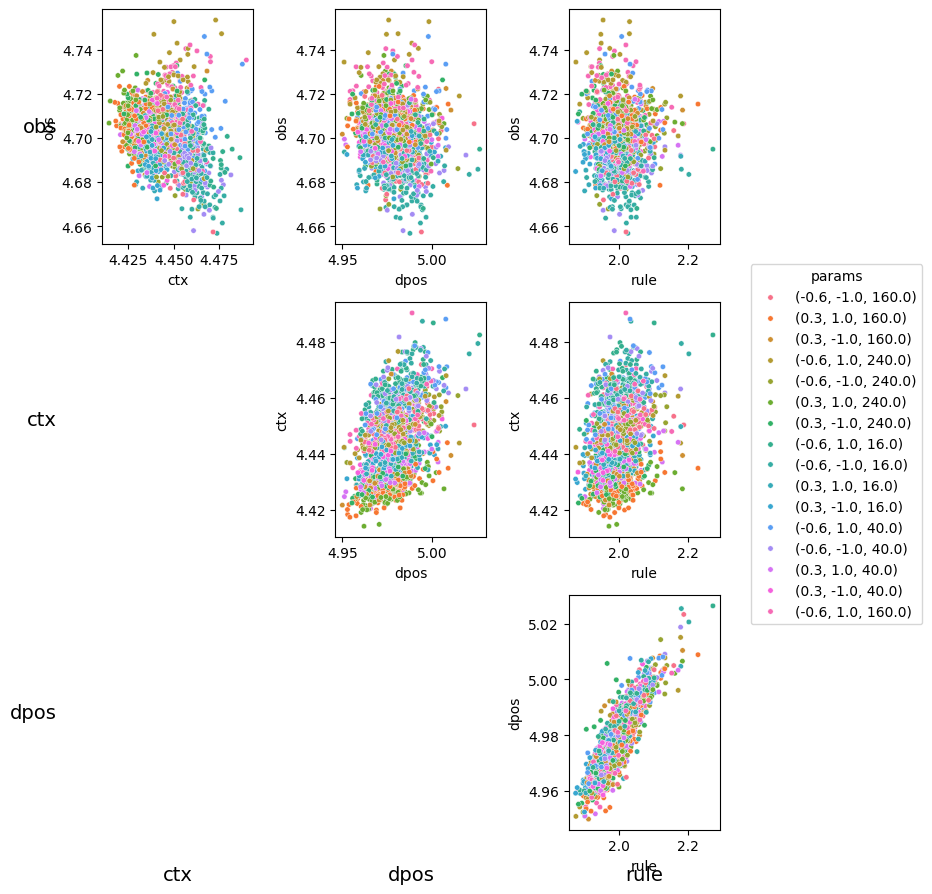

In [18]:
# Plot matrix (we only care about the upper triangle so we can leave the diagonal and lower triangle empty) showing scatterplot association between the activaty of two modules
# For this, we shouldn't use the correlation scores files but the activity files which are stored in /home/clevyfidel/Documents/Workspace/RNN_paradigm/RNN/exp_seq_act_output/population_network_all_bn8_lr0/activations. Each dot should show the association of the mean activity of two modules for one sequence. So there should be as many dots in each plot as sequences.

activations_folder = "/home/clevyfidel/Documents/Workspace/RNN_paradigm/RNN/exp_seq_act_output/population_network_all_bn8_lr0/activations"

modules = ['obs', 'ctx', 'dpos', 'rule']

# One file = one sequence. Compute the mean activity of each module within that sequence.
records = []
for f in sorted(glob.glob(os.path.join(activations_folder, "*_activations.csv"))):
    seq_df = pd.read_csv(f)
    rec = {m: seq_df[f'{m}_norm'].mean() for m in modules}
    rec['lim_std'] = seq_df['lim_std'].iloc[0]
    rec['d'] = seq_df['d'].iloc[0]
    rec['tau_std'] = seq_df['tau_std'].iloc[0]
    records.append(rec)

seq_means = pd.DataFrame(records)  # one row per sequence

# Scatterplot matrix (upper triangle only): rows = obs/ctx/dpos, cols = ctx/dpos/rule.
# Drops the always-empty left column and bottom row of the full 4x4 layout.
row_idxs = [0, 1, 2]   # obs, ctx, dpos
col_idxs = [1, 2, 3]   # ctx, dpos, rule
fig, axs = plt.subplots(3, 3, figsize=(9, 9))
hue = seq_means[['lim_std', 'd', 'tau_std']].apply(tuple, axis=1)
for ri, i in enumerate(row_idxs):
    mi = modules[i]
    for ci, j in enumerate(col_idxs):
        mj = modules[j]
        ax = axs[ri, ci]
        if j > i:
            sns.scatterplot(data=seq_means, x=mj, y=mi, hue=hue, ax=ax, s=15,
                            legend=(i == 0 and j == 1))
            ax.set_xlabel(mj)
            ax.set_ylabel(mi)
        else:
            ax.axis('off')

# Add row and column labels
for ri, i in enumerate(row_idxs):
    axs[ri, 0].text(-0.3, 0.5, modules[i], transform=axs[ri, 0].transAxes, fontsize=14, ha='right', va='center')
for ci, j in enumerate(col_idxs):
    axs[2, ci].text(0.5, -0.15, modules[j], transform=axs[2, ci].transAxes, fontsize=14, ha='center', va='top')

# Single legend to the right of the rightmost column. Reserve the strip FIRST (tight_layout(rect=...)),
# then place the legend into it -- otherwise tight_layout re-expands the axes over the legend.
handles, labels = axs[0, 0].get_legend_handles_labels()
axs[0, 0].get_legend().remove()
fig.tight_layout(rect=[0, 0, 0.84, 1])
fig.legend(handles, labels, title='params', loc='center left', bbox_to_anchor=(0.85, 0.5))


### Per timestep, for one sequence only

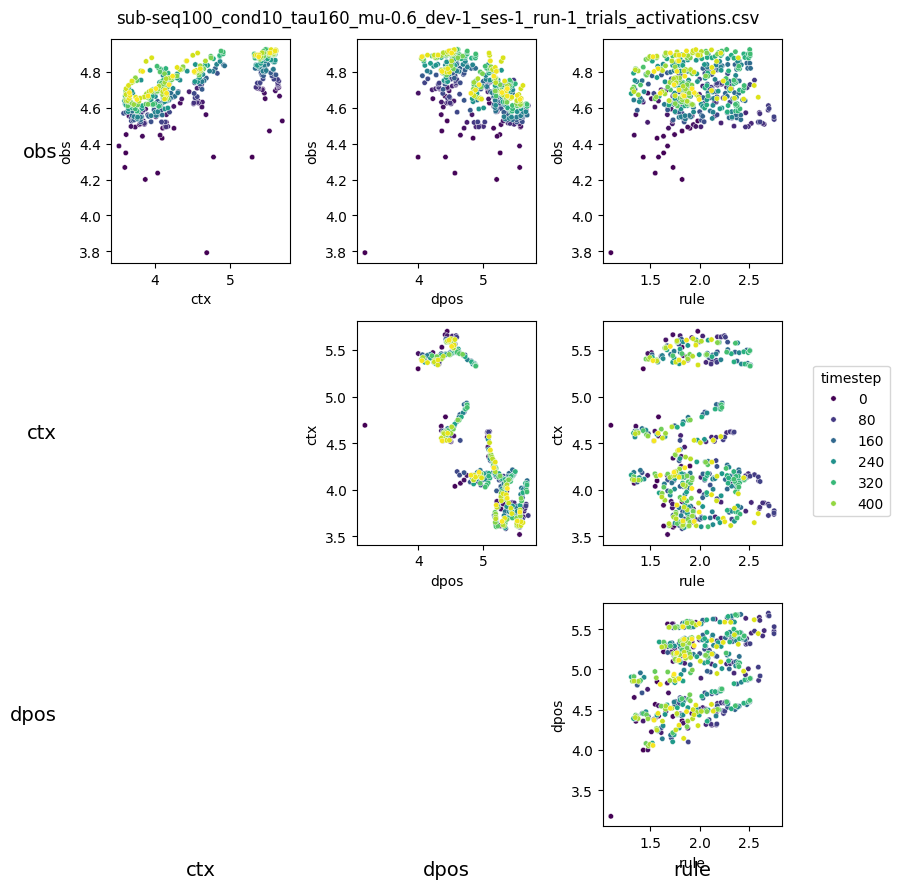

In [19]:
# Now similar analysis but sequence-wise. I.e. one dot is one pair of actities of two modules, but at each time step. So there are as many dots in one plot as timesteps in the sequence. Taking the first sequence as example

seq_files = sorted(glob.glob(os.path.join(activations_folder, "*_activations.csv")))
first_seq = pd.read_csv(seq_files[0])  # one row per timestep
first_seq['timestep'] = range(len(first_seq))

# Scatterplot matrix (upper triangle only): rows = obs/ctx/dpos, cols = ctx/dpos/rule. One dot per timestep.
row_idxs = [0, 1, 2]   # obs, ctx, dpos
col_idxs = [1, 2, 3]   # ctx, dpos, rule
fig, axs = plt.subplots(3, 3, figsize=(9, 9))
for ri, i in enumerate(row_idxs):
    mi = modules[i]
    for ci, j in enumerate(col_idxs):
        mj = modules[j]
        ax = axs[ri, ci]
        if j > i:
            sns.scatterplot(data=first_seq, x=f'{mj}_norm', y=f'{mi}_norm',
                            hue='timestep', palette='viridis', ax=ax, s=15,
                            legend=(i == 0 and j == 1))
            ax.set_xlabel(mj)
            ax.set_ylabel(mi)
        else:
            ax.axis('off')

# Add row and column labels
for ri, i in enumerate(row_idxs):
    axs[ri, 0].text(-0.3, 0.5, modules[i], transform=axs[ri, 0].transAxes, fontsize=14, ha='right', va='center')
for ci, j in enumerate(col_idxs):
    axs[2, ci].text(0.5, -0.15, modules[j], transform=axs[2, ci].transAxes, fontsize=14, ha='center', va='top')

# Single legend to the right of the rightmost column. Reserve the strip FIRST (tight_layout(rect=...)),
# then place the legend into it -- otherwise tight_layout re-expands the axes over the legend.
handles, labels = axs[0, 0].get_legend_handles_labels()
axs[0, 0].get_legend().remove()
fig.suptitle(os.path.basename(seq_files[0]), fontsize=12)
fig.tight_layout(rect=[0, 0, 0.9, 1])
fig.legend(handles, labels, title='timestep', loc='center left', bbox_to_anchor=(0.91, 0.5))


# Per timestep, averaged over sequences

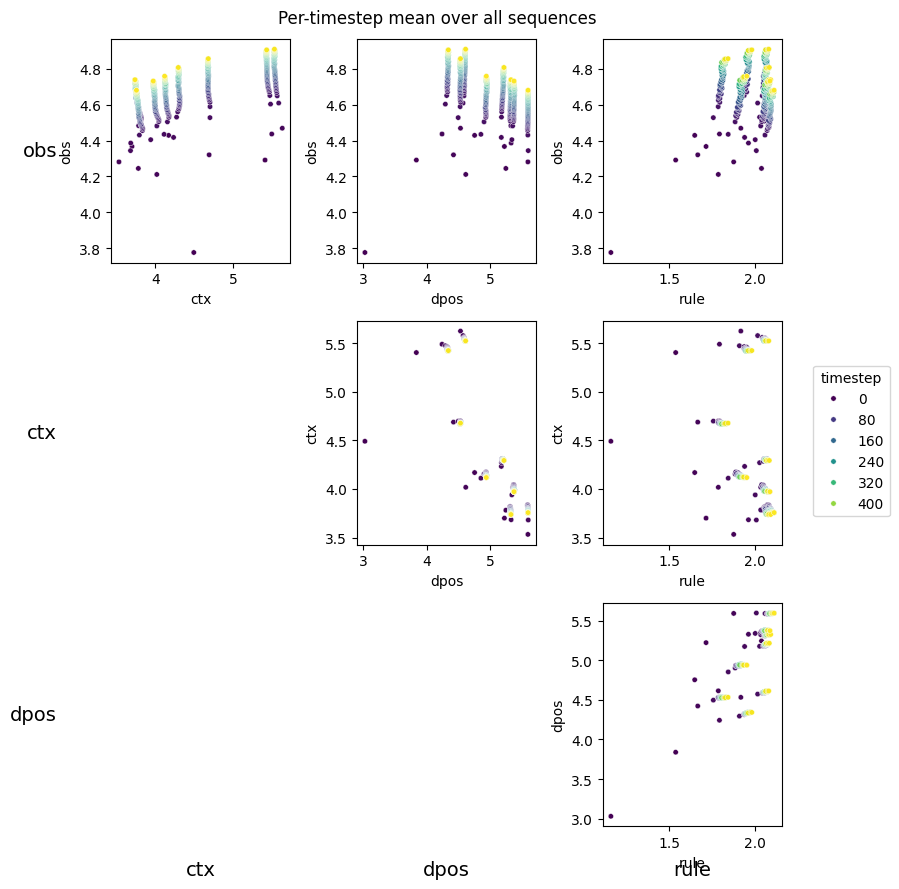

In [20]:
# Now same as first matrix but instead of showing one average per sequence and plotting all averages between sequences, we show the average per timestep over all sequences and thus have one dot per timestep. So the color code should be the same as in the second matrix

# Stack every sequence and average each module activity per timestep over all sequences.
per_ts = []
for f in seq_files:
    seq_df = pd.read_csv(f)
    sub = seq_df[[f'{m}_norm' for m in modules]].copy()
    sub['timestep'] = range(len(sub))
    per_ts.append(sub)

ts_means = pd.concat(per_ts).groupby('timestep').mean().reset_index()  # one row per timestep

# Scatterplot matrix (upper triangle only): rows = obs/ctx/dpos, cols = ctx/dpos/rule. One dot per timestep.
row_idxs = [0, 1, 2]   # obs, ctx, dpos
col_idxs = [1, 2, 3]   # ctx, dpos, rule
fig, axs = plt.subplots(3, 3, figsize=(9, 9))
for ri, i in enumerate(row_idxs):
    mi = modules[i]
    for ci, j in enumerate(col_idxs):
        mj = modules[j]
        ax = axs[ri, ci]
        if j > i:
            sns.scatterplot(data=ts_means, x=f'{mj}_norm', y=f'{mi}_norm',
                            hue='timestep', palette='viridis', ax=ax, s=15,
                            legend=(i == 0 and j == 1))
            ax.set_xlabel(mj)
            ax.set_ylabel(mi)
        else:
            ax.axis('off')

# Add row and column labels
for ri, i in enumerate(row_idxs):
    axs[ri, 0].text(-0.3, 0.5, modules[i], transform=axs[ri, 0].transAxes, fontsize=14, ha='right', va='center')
for ci, j in enumerate(col_idxs):
    axs[2, ci].text(0.5, -0.15, modules[j], transform=axs[2, ci].transAxes, fontsize=14, ha='center', va='top')

# Single legend to the right of the rightmost column. Reserve the strip FIRST (tight_layout(rect=...)),
# then place the legend into it -- otherwise tight_layout re-expands the axes over the legend.
handles, labels = axs[0, 0].get_legend_handles_labels()
axs[0, 0].get_legend().remove()
fig.suptitle('Per-timestep mean over all sequences', fontsize=12)
fig.tight_layout(rect=[0, 0, 0.9, 1])
fig.legend(handles, labels, title='timestep', loc='center left', bbox_to_anchor=(0.91, 0.5))

#### COMMENT:
# progression through the sequence (timesteps increasing) --> association of activations move up vertically / right horizontally / towards a center in the upper right corner but not extreme upper right borders (=increase with progression through sequence)


### Per timestep, averaged over sequences, per position

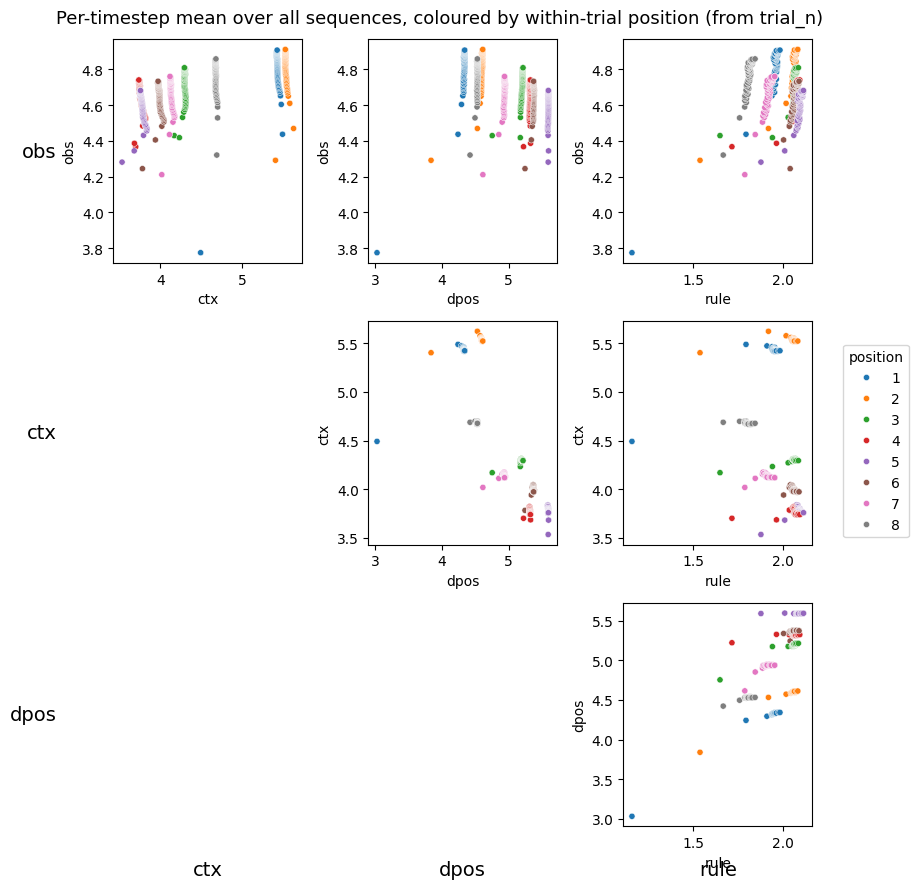

In [21]:
trial_act_folder = "/home/clevyfidel/Documents/Workspace/RNN_paradigm/RNN/exp_seq_act_output/population_network_all_bn8_lr0/activations"
seq_files_tn = sorted(glob.glob(os.path.join(trial_act_folder, "*_activations.csv")))

per_ts = []
for f in seq_files_tn:
    seq_df = pd.read_csv(f)
    sub = seq_df[[f'{m}_norm' for m in modules]].copy()
    sub['timestep'] = range(len(sub))
    sub['position'] = seq_df.groupby('trial_n').cumcount()  # 0-based index of the timestep within its trial
    per_ts.append(sub)

ts_means = pd.concat(per_ts).groupby('timestep').mean().reset_index()  # one row per timestep
ts_means['position'] = ts_means['position'].round().astype(int) + 1    # 1-based within-trial position (consistent across sequences)
pos_order = [str(p) for p in sorted(ts_means['position'].unique())]
ts_means['position'] = ts_means['position'].astype(str)                # categorical -> discrete colours; column name -> legend title "position"

# Same upper-triangle matrix (rows = obs/ctx/dpos, cols = ctx/dpos/rule), one colour per within-trial position.
row_idxs = [0, 1, 2]   # obs, ctx, dpos
col_idxs = [1, 2, 3]   # ctx, dpos, rule
fig, axs = plt.subplots(3, 3, figsize=(9, 9))
for ri, i in enumerate(row_idxs):
    mi = modules[i]
    for ci, j in enumerate(col_idxs):
        mj = modules[j]
        ax = axs[ri, ci]
        if j > i:
            sns.scatterplot(data=ts_means, x=f'{mj}_norm', y=f'{mi}_norm', hue='position',
                            hue_order=pos_order, palette='tab10', ax=ax, s=20,
                            legend=(i == 0 and j == 1))
            ax.set_xlabel(mj)
            ax.set_ylabel(mi)
        else:
            ax.axis('off')

for ri, i in enumerate(row_idxs):
    axs[ri, 0].text(-0.3, 0.5, modules[i], transform=axs[ri, 0].transAxes, fontsize=14, ha='right', va='center')
for ci, j in enumerate(col_idxs):
    axs[2, ci].text(0.5, -0.15, modules[j], transform=axs[2, ci].transAxes, fontsize=14, ha='center', va='top')

# Move the single legend to the right of the rightmost column.
handles, labels = axs[0, 0].get_legend_handles_labels()
axs[0, 0].get_legend().remove()

fig.suptitle('Per-timestep mean over all sequences, coloured by within-trial position (from trial_n)', fontsize=13)
fig.tight_layout(rect=[0, 0, 0.93, 1])  # reserve a strip on the right for the legend
fig.legend(handles, labels, title='position', loc='center left', bbox_to_anchor=(0.94, 0.5))


Text(0.9650000000000001, 0.6940000000000001, 'late t')

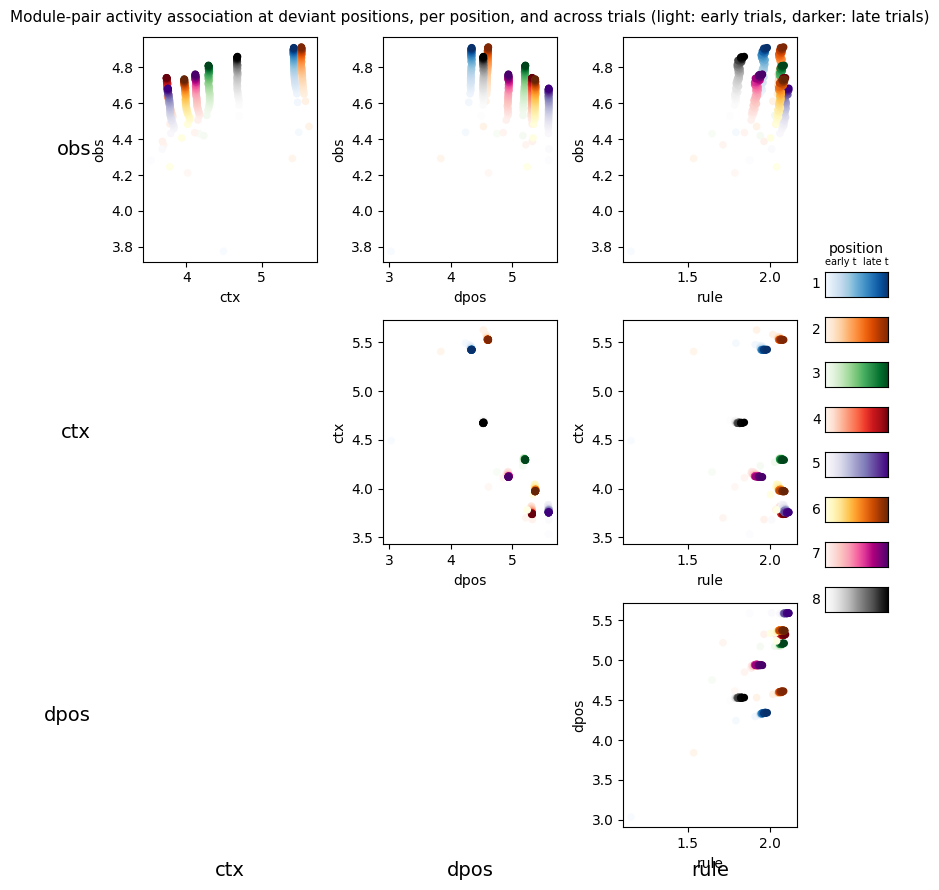

In [23]:
# Same as previous cell but trimmed to the upper triangle only:
# rows = modules[0:3] (obs, ctx, dpos), cols = modules[1:4] (ctx, dpos, rule).
# Removes the always-empty left column and bottom row from the 4×4 layout.

# positions: same order as pos_order in the previous cell (1-based within-trial position, as strings).
# CMAPS: one sequential colormap per position, hue-matched to the tab10 colors used in the previous cell
# (tab:blue, orange, green, red, purple, brown, pink, gray), so the gradient (light=early trial -> dark=late trial)
# reads as an extension of that same per-position color coding.
positions = pos_order
CMAPS = ['Blues', 'Oranges', 'Greens', 'Reds', 'Purples', 'YlOrBr', 'RdPu', 'Greys']

row_idxs = [0, 1, 2]   # obs, ctx, dpos
col_idxs = [1, 2, 3]   # ctx, dpos, rule

fig, axs = plt.subplots(3, 3, figsize=(9, 9))
for ri, i in enumerate(row_idxs):
    mi = modules[i]
    for ci, j in enumerate(col_idxs):
        mj = modules[j]
        ax = axs[ri, ci]
        if j > i:
            for p_idx, p in enumerate(positions):
                sub = ts_means[ts_means['position'] == p]
                t_min, t_max = sub['timestep'].min(), sub['timestep'].max()
                ax.scatter(sub[f'{mj}_norm'], sub[f'{mi}_norm'],
                           c=sub['timestep'], cmap=CMAPS[p_idx],
                           s=20, vmin=t_min, vmax=t_max)
            ax.set_xlabel(mj)
            ax.set_ylabel(mi)
        else:
            ax.axis('off')

for ri, i in enumerate(row_idxs):
    axs[ri, 0].text(-0.3, 0.5, modules[i], transform=axs[ri, 0].transAxes,
                    fontsize=14, ha='right', va='center')
for ci, j in enumerate(col_idxs):
    axs[2, ci].text(0.5, -0.15, modules[j], transform=axs[2, ci].transAxes,
                    fontsize=14, ha='center', va='top')

fig.suptitle('Module-pair activity association at deviant positions, per position, and across trials (light: early trials, darker: late trials)', fontsize=11)
fig.tight_layout(rect=[0, 0, 0.88, 1])

# Right-side legend: 8 stacked gradient bars, one per position.
CBAR_X   = 0.895
CBAR_W   = 0.07
CBAR_H   = 0.028
CBAR_GAP = 0.022
n = len(positions)
total_h = n * CBAR_H + (n - 1) * CBAR_GAP
top_y = 0.5 + total_h / 2

gradient = np.linspace(0, 1, 256).reshape(1, -1)

for p_idx, p in enumerate(positions):
    y0 = top_y - p_idx * (CBAR_H + CBAR_GAP) - CBAR_H
    cax = fig.add_axes([CBAR_X, y0, CBAR_W, CBAR_H])
    cax.imshow(gradient, aspect='auto', cmap=CMAPS[p_idx])
    cax.set_xticks([]); cax.set_yticks([])
    fig.text(CBAR_X - 0.005, y0 + CBAR_H / 2, str(p),
             va='center', ha='right', fontsize=10)

fig.text(CBAR_X + CBAR_W / 2, top_y + 0.018, 'position',
         ha='center', va='bottom', fontsize=10)
fig.text(CBAR_X,           top_y + 0.005, 'early t', ha='left',  va='bottom', fontsize=7)
fig.text(CBAR_X + CBAR_W, top_y + 0.005, 'late t',  ha='right', va='bottom', fontsize=7)